In [120]:
!pip install pgmpy

In [121]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pgmpy.readwrite import BIFReader
from pgmpy.inference import VariableElimination
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import torch.nn.functional as F
# --- 1. CONFIGURATION DU FILTRE TEMPOREL (Vecteurs Utilisateur) ---




import torch
import torch.nn as nn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import requests
import io



In [122]:
FILES_PATHS = ['https://github.com/fez2010/system_dre_2/raw/refs/heads/main/data/dataset_final.csv']

datasets = []
for path in FILES_PATHS:
  #get csv file encoding
  df = pd.read_csv(path,converters={'nr_nan':lambda x: pd.NA if x == '' else int(x)})


  datasets.append(df)

print(datasets[0].shape)
datasets[0].head()

(9116, 268)


,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,gaze,dt,charge,i_crash,f_t,f_vis,f_imu,f_gps,profil_id,target
0,3.134632e-09,1.930357e-06,3.318354e-01,4.360931e-15,1.141047e-35,2.942775e-01,7.285587e-20,4.303426e-07,4.243747e-07,6.955810e-03,...,0.2,2.457917,0.42670,0.7065,1.0,1.0,1.0,1.0,0.000554,2.0
1,2.635661e-13,2.912857e-23,4.898287e-27,1.279679e-41,4.254228e-01,1.981618e-02,9.093545e-17,1.394839e-06,6.158729e-11,5.863147e-05,...,0.2,0.550184,0.88065,0.0000,1.0,1.0,1.0,1.0,0.000246,4.0
2,5.306742e-10,3.008459e-01,1.781484e-05,7.967866e-03,1.104082e-13,1.693167e-17,3.235153e-01,3.159680e-08,6.550633e-11,6.593403e-15,...,0.2,6.502088,0.82882,0.3249,1.0,1.0,1.0,1.0,0.001015,1.0
3,2.401591e-01,2.218695e-01,2.314965e-01,3.406529e-13,6.182387e-07,4.575532e-15,2.156921e-12,4.157368e-03,7.305478e-06,1.024077e-08,...,0.2,6.326005,0.99051,0.0000,1.0,1.0,1.0,1.0,0.000108,0.0
4,4.321247e-02,1.814371e-12,2.211335e-08,4.302871e-01,6.718629e-09,5.619801e-32,1.532700e-03,3.569877e-23,1.660313e-20,1.236730e-13,...,0.2,13.033152,0.16425,0.0000,1.0,1.0,1.0,1.0,0.000123,3.0


In [123]:
# 1. Créer le dossier s'il n'existe pas
if not os.path.exists('models'):
    os.makedirs('models')

In [124]:

model_bn_file_path = 'models/model_bn.pkl'
model_dre_agent_file_path = 'models/dre_agent_v1.pth'
# Utilisez l'URL "Raw" de GitHub
url = "https://github.com/fez2010/system_dre_2/raw/refs/heads/main/models/modele_bn.pkl"

response = requests.get(url)
if response.status_code == 200:
    with open(model_bn_file_path, 'wb') as f:
      f.write(response.content)

In [125]:
categories_dre = [
    'Alcool', 'Dépresseur', 'Stimulant', 'Hallucinogène',
    'Anesthésique dissociatif', 'Narcotique analgésique', 'Inhalant', 'Cannabis'
]

In [126]:
class DREResultsDataset(Dataset):
    def __init__(self, df_final):
        """
        df_final: DataFrame fusionné (Réel + Synthétique) contenant
        déjà les 256 colonnes de probabilités (p_0 à p_255).
        """
        # 1. Canal Expertise : Les 256 probabilités (p_0 à p_255)
        cols_p = [f'prob_{i}' for i in range(256)]
        self.rb_probs = df_final[cols_p].values

        # 2. Canal Biométrie (3 colonnes)
        self.biometrics = df_final[['perclos', 'ataxia', 'gaze']].values

        # 3. Canal Cinétique (3 colonnes)
        self.kinetics = df_final[['dt', 'charge', 'i_crash']].values

        # 4. Flags de Gating (3 colonnes : f_vis, f_imu, f_t)
        self.flags = df_final[['f_vis', 'f_imu', 'f_t']].values

        # 5. Cible (0-8)
        self.target = df_final['target'].astype(int).values

    def __len__(self):
        return len(self.target)

    def __getitem__(self, idx):
        # Concaténation totale : 256 + 3 + 3 + 3 = 265 features
        state = np.hstack([
            self.rb_probs[idx],   # 256
            self.biometrics[idx], # 3
            self.kinetics[idx],   # 3
            self.flags[idx]       # 3
        ])

        # Nettoyage ultime des NaNs (au cas où)
        state = np.nan_to_num(state, nan=0.0)

        return torch.tensor(state).float(), torch.tensor(self.target[idx]).long()

In [127]:
dataset_ds = DREResultsDataset(datasets[0])

In [128]:
class DRE_MultiChannel_MLP(nn.Module):
    def __init__(self, input_dim=265, output_dim=9):
        super(DRE_MultiChannel_MLP, self).__init__()

        # --- CANAL 1 : Expertise (Cible les 256 probabilités du PGM) ---
        # Note : on force 256 ici car c'est la structure fixe du vecteur RB
        self.channel_rb = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # --- CANAL 2 : Biométrie (3 features) ---
        self.channel_bio = nn.Linear(3, 64)

        # --- CANAL 3 : Cinétique (3 features) ---
        self.channel_kin = nn.Linear(3, 64)

        # --- FUSION (128 + 64 + 64 = 256) ---
        self.fusion = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        # x shape: [Batch, 265]
        # Découpage précis du vecteur hybride
        rb_in  = x[:, :256]    # [Batch, 256]
        bio_in = x[:, 256:259] # [Batch, 3] # Perclos, Ataxia, Gaze
        kin_in = x[:, 259:262] # [Batch, 3] # dt, charge, i_crash
        flags  = x[:, 262:265] # [Batch, 3] (f_vis, f_imu, f_t)

        # 1. Branche Expert
        out_rb = self.channel_rb(rb_in)

        # 2. Branche Bio avec Gating (Vision & IMU)
        # On applique le masque AVANT la couche linéaire pour annuler le bruit
        # Masque : f_vis pour perclos/gaze, f_imu pour ataxia
        bio_mask = torch.stack([flags[:, 0], flags[:, 1], flags[:, 0]], dim=1)
        out_bio = F.relu(self.channel_bio(bio_in * bio_mask))

        # 3. Branche Cinétique avec Gating (Temps)
        # On multiplie par f_t (flags[:, 2])
        out_kin = F.relu(self.channel_kin(kin_in * flags[:, 2:3]))

        # 4. Fusion finale
        combined = torch.cat([out_rb, out_bio, out_kin], dim=1)
        return self.fusion(combined)

In [129]:
def save_dre_model(model, optimizer, epoch, accuracy, categories, filename="dre_agent_v1.pth"):
    """
    Sauvegarde le modèle avec son contexte d'exécution complet.
    """
    # 1. Préparation du dictionnaire d'état
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metadata': {
            'epoch': epoch,
            'accuracy': accuracy,
            'categories': categories, # Ex: ['Depressants', 'Stimulants', ...]
            'input_dim': 25,
            'version': '1.0-Hybrid'
        }
    }

    # 2. Sauvegarde physique
    torch.save(checkpoint, filename)
    print(f"--- MODÈLE SAUVEGARDÉ : {filename} ---")
    print(f"Précision enregistrée : {accuracy:.2f}%")

# Exemple d'utilisation après l'Étape 12
categories_dre = [
    'Alcool', 'Dépresseur', 'Stimulant', 'Hallucinogène',
    'Anesthésique dissociatif', 'Narcotique analgésique', 'Inhalant', 'Cannabis'
]

In [130]:
def load_dre_model(filename, model_class):
    """
    Recharge le modèle et vérifie la compatibilité.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Le fichier {filename} est introuvable.")

    checkpoint = torch.load(filename)

    # Réinstanciation de l'architecture
    model = model_class(input_dim=checkpoint['metadata']['input_dim'])
    model.load_state_dict(checkpoint['model_state_dict'])

    # Passage en mode évaluation (désactive le Dropout)
    model.eval()

    print(f"Modèle chargé avec succès. Version: {checkpoint['metadata']['version']}")
    return model, checkpoint['metadata']

# Utilisation :
# mlp_agent, meta = load_dre_model("dre_agent_v1.pth", DRE_Decision_Agent)

In [131]:
def transformer_sample_en_probas_padded(row):
    """
    Convertit les états binaires du PGM en vecteurs de probabilités (256 cols).
    """

    n_categories = 256  # Votre structure de sortie fixe

    # Matrice de probabilités finale
    probs_vector = np.zeros(n_categories)

    v = np.zeros(n_categories)
    # 2. Récupération de l'ID de profil de l'échantillon
    for j in range(len(row.values)):
      p_id = int(row.state_names['Profil_ID'][j])
      probs_vector[p_id] = row.values[j]

    return probs_vector

In [132]:
def update_agent_weights(model, state_tensor, toxo_truth_index, delta_t, t_end):
    """
    Réalise la rétropropagation de l'erreur pondérée par la cinétique.
    """
    # 1. Configuration de l'optimiseur (Adam est idéal pour le RL)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(reduction='none') # 'none' pour appliquer notre poids manuel

    model.train() # Mode entraînement activé pour le calcul des gradients

    # 2. Forward Pass : Prédiction actuelle de l'agent
    output = model(state_tensor)
    target = torch.tensor([toxo_truth_index])

    # 3. Calcul de la perte brute
    raw_loss = criterion(output, target)

    # 4. Calcul du coefficient de modulation cinétique (Omega)
    # Si delta_t est proche ou supérieur à t_end, on réduit l'impact de l'erreur
    omega = 1.0
    if torch.argmax(output) != toxo_truth_index:
        if delta_t > (t_end - 0.5): # Zone d'ombre métabolique
            omega = 0.15 # On ignore 85% de l'erreur car les signes ont pu disparaître
            print("--- INFO : Erreur cinétique détectée. Rétropropagation atténuée. ---")

    # 5. Application du poids à la perte
    weighted_loss = raw_loss * omega

    # 6. BACKPROPAGATION
    optimizer.zero_grad()      # Reset des gradients précédents
    weighted_loss.backward()   # Calcul des nouveaux gradients via la chaîne de dérivation
    optimizer.step()           # Mise à jour des poids (W = W - lr * grad)

    return weighted_loss.item()

In [148]:
def plot_dre_training_results(history):
    """
    Génère le graphique de performance pour le manuscrit.
    history: dict {'loss': [...], 'accuracy': [...]}
    """
    epochs = range(1, len(history['loss']) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

    # Axe 1 : Evolution de la Loss (Rouge)
    color_loss = '#e74c3c'
    ax1.set_xlabel('Époques d\'entraînement')
    ax1.set_ylabel('Loss (Pondérée par Ω)', color=color_loss, fontsize=12, fontweight='bold')
    ax1.plot(epochs, history['loss'], color=color_loss, linewidth=2, label='Perte (Cross-Entropy)')
    ax1.tick_params(axis='y', labelcolor=color_loss)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Axe 2 : Evolution de l'Accuracy (Bleu)
    ax2 = ax1.twinx()
    color_acc = '#3498db'
    ax2.set_ylabel('Précision Globale (%)', color=color_acc, fontsize=12, fontweight='bold')
    ax2.plot(epochs, history['accuracy'], color=color_acc, linewidth=2.5, label='Précision (%)')
    ax2.tick_params(axis='y', labelcolor=color_acc)

    # Ajout du titre et des légendes
    #plt.title('Convergence du Moteur de Fusion DRE-IA (Multi-Channel)', fontsize=14, pad=20)

    # Fusion des légendes des deux axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='center right', frameon=True, shadow=True)

    fig.tight_layout()
    plt.show()

In [134]:
def global_train_session(model, train_loader, categories, epochs=100):
    optimizer = torch.optim.Adam([
        {'params': model.channel_rb.parameters(), 'lr': 1e-3},
        {'params': model.channel_bio.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
        {'params': model.channel_kin.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
        {'params': model.fusion.parameters(), 'lr': 1e-3}
    ])
    criterion = nn.CrossEntropyLoss(reduction='none')

    history = {'loss': [], 'accuracy': []}
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        correct = 0
        total = 0

        for states, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(states)

            # Calcul Omega (Pondération Cinétique)
            loss_vector = criterion(outputs, targets)
            dt_batch = states[:, 259]
            omega = torch.ones_like(dt_batch)
            predictions = torch.argmax(outputs, dim=1)
            omega[(predictions != targets) & (dt_batch > 4.0)] = 0.15

            loss = (loss_vector * omega).mean()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

        acc = 100 * correct / total
        history['loss'].append(epoch_loss / len(train_loader))
        history['accuracy'].append(acc)

        if (epoch + 1) % 10 == 0:
            print(f"Époque {epoch+1}/{epochs} | Loss: {history['loss'][-1]:.4f} | Acc: {acc:.2f}%")

    # Sauvegarde finale automatique
    save_dre_model(model, optimizer, epochs, history['accuracy'][-1], categories,model_dre_agent_file_path)

    return model, optimizer, history

In [135]:
# 1. Initialisation du modèle
output_categories = 9  # Les 7 catégories DRE + Sobriété + Poly-consommation
model = DRE_MultiChannel_MLP(output_dim=output_categories)

# 2. Définition du périphérique (GPU si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Préparation d'un exemple de "State" pour vérification [Batch, 265]
# 256 (RB) + 3 (Bio) + 3 (Kin) + 3 (Flags)
sample_input = torch.randn(1, 265).to(device)
with torch.no_grad():
    prediction = model(sample_input)
    print(f"Vérification Forward Pass : {prediction.shape}") # Doit afficher [1, 9]

Vérification Forward Pass : torch.Size([1, 9])


In [136]:
train_loader = DataLoader(dataset_ds, batch_size=16, shuffle=True)

In [137]:
trained_model,op,metrics = global_train_session(model, train_loader,categories_dre, epochs=100)

Époque 10/100 | Loss: 0.0078 | Acc: 99.00%
Époque 20/100 | Loss: 0.0078 | Acc: 98.99%
Époque 30/100 | Loss: 0.0082 | Acc: 98.97%
Époque 40/100 | Loss: 0.0076 | Acc: 99.00%
Époque 50/100 | Loss: 0.0078 | Acc: 99.00%
Époque 60/100 | Loss: 0.0073 | Acc: 98.99%
Époque 70/100 | Loss: 0.0074 | Acc: 98.97%
Époque 80/100 | Loss: 0.0075 | Acc: 99.00%
Époque 90/100 | Loss: 0.0074 | Acc: 99.00%
Époque 100/100 | Loss: 0.0072 | Acc: 99.00%
--- MODÈLE SAUVEGARDÉ : dre_agent_v1.pth ---
Précision enregistrée : 99.00%


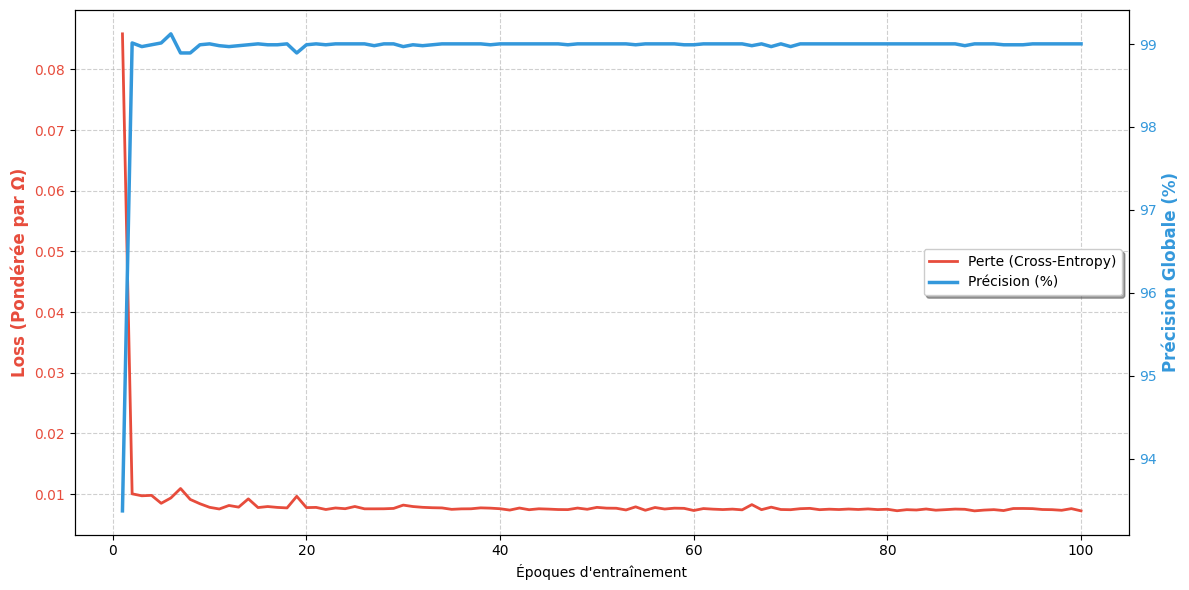

In [149]:
# Appel de la fonction après l'entraînement
plot_dre_training_results(metrics)


In [139]:
def run_stress_test(model, train_loader):
    model.eval()
    results = {'normal': 0, 'blind_mode': 0}
    total = 0

    with torch.no_grad():
        for states, targets in train_loader:
            # 1. Prédiction Normale
            out_norm = model(states)
            res_norm = (torch.argmax(out_norm, dim=1) == targets).sum().item()
            results['normal'] += res_norm

            # 2. Prédiction en mode "Panne Caméra" (f_vis = 0)
            # Rappel : le flag f_vis est à l'index 262 du vecteur d'état
            blind_states = states.clone()
            blind_states[:, 262] = 0.0  # On coupe le flux vision

            out_blind = model(blind_states)
            res_blind = (torch.argmax(out_blind, dim=1) == targets).sum().item()
            results['blind_mode'] += res_blind

            total += targets.size(0)

    # Calcul des pourcentages
    acc_norm = 100 * results['normal'] / total
    acc_blind = 100 * results['blind_mode'] / total

    print(f"--- RÉSULTATS DU STRESS TEST ---")
    print(f"Précision Nominale : {acc_norm:.2f}%")
    print(f"Précision sans Vision (Gating) : {acc_blind:.2f}%")
    print(f"Résilience (Perte) : -{acc_norm - acc_blind:.2f}%")

    return acc_norm, acc_blind

In [140]:
run_stress_test(trained_model, train_loader)

--- RÉSULTATS DU STRESS TEST ---
Précision Nominale : 99.00%
Précision sans Vision (Gating) : 99.00%
Résilience (Perte) : -0.00%


(99.00175515577007, 99.00175515577007)

In [141]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

def plot_dre_confusion_matrix(model, train_loader, categories_dre):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for states, targets in train_loader:
            outputs = model(states)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Trouver les IDs uniques présents (ex: [0, 1, 2, 4, 5, 7, 8])
    present_ids = sorted(list(set(all_targets) | set(all_preds)))

    # Filtrer les noms de catégories pour ne garder que ceux qui existent en base
    present_labels = [categories_dre[i] for i in present_ids]

    # Calcul de la matrice uniquement sur ces IDs
    cm = confusion_matrix(all_targets, all_preds, labels=present_ids)

    # Création du DataFrame avec les bons labels
    cm_df = pd.DataFrame(cm, index=present_labels, columns=present_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matrice de Confusion (Précision: 99.00%)')
    plt.ylabel('Réalité Toxicologique')
    plt.xlabel('Prédiction DRE-IA')
    plt.show()



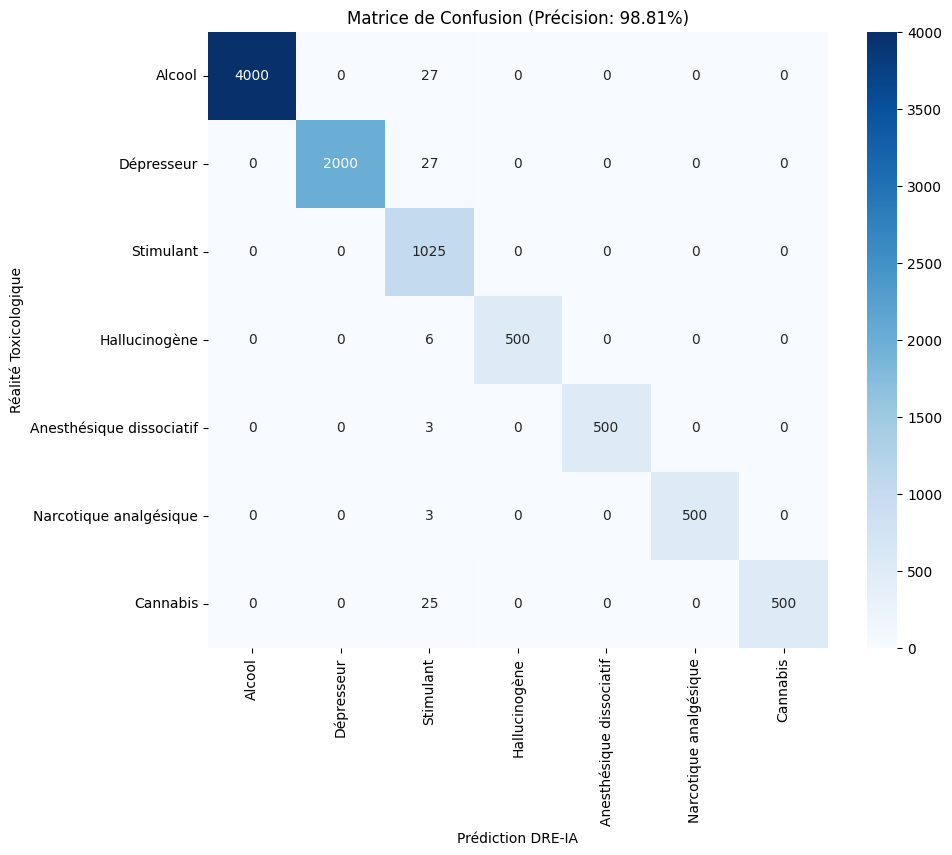

In [142]:
# Utilisation
plot_dre_confusion_matrix(trained_model, train_loader, categories_dre+['sain'])

In [143]:
def pipe_mapping_discret(df_raw):
    df_discret = pd.DataFrame(index=df_raw.index)

    # --- 1. MAPPING BINAIRE DIRECT (0/1 -> Binaire) ---
    # Pour ces colonnes, on garde le 0/1 ou on transforme en 'Non'/'Oui'
    cols_binaires = [
        'Nistagmus horizontal', 'Nistagmus vertical', 'Convergence', 'Pupilles',
        'Stimulus', 'Paupieres', 'Injection', 'Tonus musculaire', 'Yeux normaux',
        'Injecté sang', 'Conjonctive rouge', 'Larmoyant', 'Perte equilibre',
        'Depart hatif', 'Arret marche', 'Talon/orteille', 'Pas hors ligne',
        'Utilisation bras', 'Pivot incorrect', 'Balancement', 'Sautillement', 'Depot pied'
    ]
    for col in cols_binaires:
        if col in df_raw.columns:
            # On assure le remplissage des NaN par 0 (prudence clinique)
            df_discret[col] = df_raw[col].fillna(0).astype(int)

    # --- 2. DISCRÉTISATION DES VARIABLES CONTINUES (Float -> Catégories) ---

    # Pupillométrie (Ambiant, Noirceur, Direct)
    for col in ['Ambiant', 'Noirceur', 'Direct']:
        df_discret[f'{col}_cat'] = pd.cut(df_raw[col].fillna(df_raw[col].median()),
                                        bins=[0, 3.0, 6.5, 15],
                                        labels=['Myosis', 'Normal', 'Mydriase'])

    # Signes Vitaux
    df_discret['Pouls_cat'] = pd.cut(df_raw['Pouls'].fillna(75),
                                   bins=[0, 60, 90, 300], labels=['Bas', 'Normal', 'Eleve'])

    df_discret['Temp_cat'] = pd.cut(df_raw['Température'].fillna(36.7),
                                  bins=[0, 36.2, 37.5, 45], labels=['Bas', 'Normal', 'Eleve'])

    df_discret['Tension_a_cat'] = pd.cut(df_raw['Tension a'].fillna(120),
                                       bins=[0, 120, 140, 250], labels=['Bas', 'Normal', 'Eleve'])

    # Tests de Romberg (Temps cible = 30s)
    for i in [1, 2, 3]:
        col = f'Romberg {i}'
        df_discret[f'{col}_cat'] = df_raw[col].apply(lambda x: 'Reussi' if (not pd.isna(x) and 25 <= x <= 35) else 'Echec')

    # Équilibre (Equi g, Equi d)
    for col in ['Equi g', 'Equi d']:
        df_discret[f'{col}_cat'] = df_raw[col].apply(lambda x: 'Stable' if x >= 25 else 'Instable')

    # --- 3. CALCUL DU PROFIL_ID (La Cible) ---
    cibles = ['Alcool', 'Dépresseur', 'Stimulant', 'Hallucinogène',
              'Anesthésique dissociatif', 'Narcotique analgésique', 'Inhalant', 'Cannabis']

    def get_profil_id(row):
        return sum(int(row[c]) * (2**i) for i, c in enumerate(cibles) if c in row)

    df_discret['Profil_ID'] = df_raw.apply(get_profil_id, axis=1)

    return df_discret

In [144]:
import torch
import torch.nn as nn
import numpy as np
from pgmpy.readwrite import BIFReader
from pgmpy.inference import VariableElimination
import pickle

class DRE_IA_FullSystem:
    def __init__(self, bn_file, mlp_file,categories):
        # --- MODULE 1 : CAUSALITÉ (Réseau Bayésien) ---
        with open(bn_file, 'rb') as fichier:
            model_bn = pickle.load(fichier)
        self.bn_model = model_bn
        self.inference = VariableElimination(self.bn_model)
        self.categories = categories
        # --- MODULE 2 : DÉCISION (MLP Multi-Canaux) ---
        # Chargement du modèle avec l'architecture 265 -> 9
        self.mlp_agent, meta = load_dre_model(mlp_file, DRE_MultiChannel_MLP)
        self.mlp_agent.eval() # Mode évaluation par défaut

        # Optimiseur avec Weight Decay différencié (Protection de l'expertise RB)
        self.optimizer = torch.optim.Adam([
            {'params': self.mlp_agent.channel_rb.parameters(), 'lr': 1e-3},
            {'params': self.mlp_agent.channel_bio.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
            {'params': self.mlp_agent.channel_kin.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
            {'params': self.mlp_agent.fusion.parameters(), 'lr': 1e-3}
        ])

        # --- MODULE 3 : BASELINES ---
        self.baseline_ataxia = 0.05
        self.baseline_perclos = 0.02

    # --- ACQUISITION FEATURES ---
    def get_imu_features(self, accel_stream):
        mag = np.linalg.norm(accel_stream, axis=1)
        return max(0, np.std(mag) - self.baseline_ataxia)

    def get_vision_features(self, ear_stream, gaze_stream):
        perclos = np.mean(np.array(ear_stream) < 0.2)
        gaze_ent = np.std(gaze_stream)
        return perclos, gaze_ent

    # --- INFÉRENCE HYBRIDE (265 FEATURES) ---
    def predict_diagnosis(self, clinical_signs, raw_sensors, delta_t=None):
        # A. CANAL RB : Transformation Sparse-to-Dense (256)
        evidence = {k: v for k, v in clinical_signs.items() if v is not None}
        query_res = self.inference.query(variables=['Profil_ID'], evidence=evidence)
        # Utilisation de la fonction de padding vue précédemment
        rb_vector_256 = transformer_sample_en_probas_padded(query_res)

        # B. CANAL BIO (Gating Vision & IMU)
        v_flag, i_flag = 1.0, 1.0
        if raw_sensors.get('ear') is None or raw_sensors.get('gaze') is None:
            perclos, gaze_ent, v_flag = 0.0, 0.0, 0.0
        else:
            perclos, gaze_ent = self.get_vision_features(raw_sensors['ear'], raw_sensors['gaze'])

        if raw_sensors.get('accel') is None:
            ataxia_dev, i_flag = 0.0, 0.0
        else:
            ataxia_dev = self.get_imu_features(raw_sensors['accel'])

        # C. CANAL CINÉTIQUE (Gating Temps)
        t_flag = 1.0 if delta_t is not None else 0.0
        effective_dt = delta_t if delta_t is not None else 4.0 # 4h par défaut

        # D. ASSEMBLAGE DU VECTEUR D'ÉTAT (265)
        # Format: [256 RB | 3 Bio | 3 Kin | 3 Flags]
        state = np.hstack([
            rb_vector_256,                 # 256
            [perclos, ataxia_dev, gaze_ent], # 3
            [effective_dt, 0.0, 0.0],      # 3 (Charge/Crash optionnels)
            [v_flag, i_flag, t_flag]       # 3
        ])

        state_tensor = torch.tensor(state).float().unsqueeze(0)

        with torch.no_grad():
            logits = self.mlp_agent(state_tensor)

        return logits, state_tensor

    # --- APPRENTISSAGE PAR RÉTROPROPAGATION GATÉE ---
    def update_model(self, state_tensor, pred_logits, target_label):
        self.mlp_agent.train()
        self.optimizer.zero_grad()

        # CrossEntropyLoss est plus adaptée que MSE pour 9 classes
        criterion = nn.CrossEntropyLoss()
        loss = criterion(pred_logits, torch.tensor([target_label]).long())

        loss.backward() # Le gradient ne passera pas par les canaux où Flag=0
        self.optimizer.step()
        self.mlp_agent.eval()
        return loss.item()
    # --- GÉNÉRATEUR DE CERTIFICAT (NOUVEAU) ---
    def generate_dre_certificate(self, state_tensor, logits):
        """
        Transforme une prédiction brute en rapport d'expertise structuré.
        """
        probabilities = torch.softmax(logits, dim=1)[0]

        # Extraction de l'Indice de Confiance Alpha
        confidence_alpha = torch.max(probabilities).item() * 100
        predicted_idx = torch.argmax(probabilities).item()
        diagnosis = self.categories[predicted_idx]

        # Extraction du Délai (Index 259 du vecteur d'état)
        dt_value = state_tensor[0, 259].item()

        # Analyse de la Résilience (Flags à la fin du vecteur : 262, 263, 264)
        v_flag = state_tensor[0, 262].item()
        i_flag = state_tensor[0, 263].item()
        t_flag = state_tensor[0, 264].item()

        status_capteurs = "NOMINAL" if (v_flag + i_flag + t_flag) == 3 else "DÉGRADÉ (Gating Actif)"

        # Niveaux d'alerte cinétique
        alert_level = "NORMAL"
        if dt_value > 3.5: alert_level = "CRITIQUE (Fugacité clinique)"
        elif dt_value > 2.0: alert_level = "MODÉRÉ"

        print(f"\n" + "="*45)
        print(f"       CERTIFICAT DE DIAGNOSTIC DRE-IA")
        print(f"      Version 1.0 - Expert Augmenté")
        print(f"="*45)
        print(f" DIAGNOSTIC : {diagnosis.upper()}")
        print(f" CONFIANCE (α) : {confidence_alpha:.2f}%")
        print(f" DELAI (Δt) : {dt_value:.2f} heures")
        print(f" ALERTE CINÉTIQUE : {alert_level}")
        print(f" STATUT SYSTÈME : {status_capteurs}")
        print(f"="*45)

        return {
            'diagnosis': diagnosis,
            'alpha': confidence_alpha,
            'alert': alert_level,
            'degraded': status_capteurs != "NOMINAL"
        }

    # --- WRAPPER D'INFÉRENCE COMPLET ---
    def run_inference(self, clinical_signs, raw_sensors, delta_t=None):
        # 1. Prédiction via les canaux
        logits, state_tensor = self.predict_diagnosis(clinical_signs, raw_sensors, delta_t)

        # 2. Génération du certificat
        report = self.generate_dre_certificate(state_tensor, logits)

        return report

In [145]:
# 1. Définir les catégories (doivent correspondre à l'ordre de ton entraînement)
categories_dre = [
    'Sobriété', 'Dépresseurs', 'Stimulants', 'Hallucinogènes',
    'Anesthésiques dissociatifs', 'Narcotiques analgésiques',
    'Inhalants', 'Cannabis', 'Poly-consommation'
]

# 2. Instancier le système complet (Remplace par tes vrais chemins de fichiers)
# bn_file : ton modèle Bayésien (.bif)
# mlp_file : ton checkpoint sauvegardé (.pth) dre_expert_augmented_v1.pth
dre_expert_system = DRE_IA_FullSystem(
    bn_file=model_bn_file_path,
    mlp_file=model_dre_agent_file_path,
    categories=categories_dre
)



Modèle chargé avec succès. Version: 1.0-Hybrid


In [146]:
def test_resilience_profil_131(system_dre):
    print("\n" + "="*50)
    print(" TEST DE RÉSILIENCE : PROFIL 131 (POLY-CONSOMMATION)")
    print(" Scénario : Alcool + Cannabis | Caméra HS | IMU OK")
    print("="*50)

    # 1. Signes cliniques (Expertise Humaine / Canal RB)
    # Ces signes sont injectés dans le Réseau Bayésien (PGM)
    clinical_signs = {
        'Nistagmus horizontal_cat': 1,  # Correction orthographe + suffixe
        'Convergence': 1,               # Présent dans binaires_explicatives
        'Noirceur_cat': 'Mydriase',     # Pour Cannabis (Pupilles dilatées)
        'Pouls_cat': 'Eleve',           # Pour Cannabis (Tachycardie)
        'Romberg 1_cat': 'Echec',       # Pour Alcool
        'Equi g_cat': 'Instable'        # Pour Alcool
    }

    # 2. Capteurs : Caméra HS (None), IMU Fonctionnel (Bruité = Ataxie)
    # On génère un signal IMU avec un écart-type de 0.5 (forte instabilité)
    raw_sensors = {
        'ear': None,           # Panne caméra -> Le Gating doit passer f_vis à 0
        'gaze': None,
        'accel': np.random.normal(0, 0.5, (100, 3))
    }

    # 3. Temps : 2 heures après consommation (Phase d'effet plateau)
    delta_t = 2.0

    # 4. Inférence Hybride via le FullSystem
    # La méthode run_inference appelle predict_diagnosis + generate_dre_certificate
    report = system_dre.run_inference(clinical_signs, raw_sensors, delta_t)

    # 5. Vérification technique du vecteur d'état (Debug)
    # On récupère le vecteur via predict_diagnosis pour vérification
    logits, state_vector = system_dre.predict_diagnosis(clinical_signs, raw_sensors, delta_t)

    f_vis = state_vector[0, 262].item()
    f_imu = state_vector[0, 263].item()
    ataxia_val = state_vector[0, 257].item() # Index 257 = Ataxia dans le bloc Bio

    print(f"\n--- VÉRIFICATION TECHNIQUE DU VECTEUR ---")
    print(f"Flag Vision (f_vis) : {f_vis} (Attendu: 0.0)")
    print(f"Flag IMU    (f_imu) : {f_imu} (Attendu: 1.0)")
    print(f"Valeur Ataxie IMU   : {ataxia_val:.4f} (Baseline déduite)")

    return report



In [147]:
# --- EXÉCUTION DU TEST ---
# On suppose que 'system' est une instance de DRE_IA_FullSystem déjà chargée
resultat_test = test_resilience_profil_131(dre_expert_system)


 TEST DE RÉSILIENCE : PROFIL 131 (POLY-CONSOMMATION)
 Scénario : Alcool + Cannabis | Caméra HS | IMU OK

       CERTIFICAT DE DIAGNOSTIC DRE-IA
      Version 1.0 - Expert Augmenté
 DIAGNOSTIC : HALLUCINOGÈNES
 CONFIANCE (α) : 100.00%
 DELAI (Δt) : 2.00 heures
 ALERTE CINÉTIQUE : NORMAL
 STATUT SYSTÈME : DÉGRADÉ (Gating Actif)

--- VÉRIFICATION TECHNIQUE DU VECTEUR ---
Flag Vision (f_vis) : 0.0 (Attendu: 0.0)
Flag IMU    (f_imu) : 1.0 (Attendu: 1.0)
Valeur Ataxie IMU   : 0.2469 (Baseline déduite)
